# Image Enhancement Autoencoder
**Recreating:** *Deep Learning Approach to Improve Image Super-Resolution with Aliasing*
(Kędzierski & Rusiecki, KES 2024)

Key contributions from the paper implemented here:
- **Deeply rebuilt autoencoder with recursive layers** (best performing model)
- **Bilateral filter anti-aliasing** as preprocessing (Table 6: improves HFEN by 0.2)
- **RELLISUR dataset** (722 train / 85 test / 43 val, 625×625 images)
- **Full metric evaluation**: SSIM, PSNR, NRMSE, VIF, MS-SSIM, UQI, HFEN

**Runtime → Change runtime type → T4 GPU**

In [ ]:
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else '❌ No GPU — change runtime!')

GPU: Tesla T4


## Step 1 — Install dependencies

In [ ]:
!pip install -q piq gdown
# piq = PyTorch Image Quality — provides SSIM, MS-SSIM, VIF, etc.
import torch, torchvision
print('✅ Dependencies ready')
print(f'PyTorch {torch.__version__} | torchvision {torchvision.__version__}')

✅ Dependencies ready
PyTorch 2.10.0+cu128 | torchvision 0.25.0+cu128


## Step 2 — Download RELLISUR dataset
*(722 train / 85 test / 43 val — 625×625 high-res images with low-light variants)*

In [ ]:
import os, glob

# RELLISUR is hosted on Kaggle — we use the official mirror
# Paper: "The RELLISUR set is a database designed to bridge the gap between
# algorithms that improve the quality of low-light images and algorithms
# that increase their resolution"
!pip install -q kaggle

# Alternative: download directly from the NeurIPS 2021 source
!wget -q --no-check-certificate \
    'https://zenodo.org/record/5578876/files/RELLISUR_dataset.zip' \
    -O RELLISUR.zip

!unzip -q RELLISUR.zip -d rellisur_data
!rm RELLISUR.zip

# If zenodo fails, fall back to DIV2K (same quality range)
if not os.path.exists('rellisur_data') or len(glob.glob('rellisur_data/**/*.png', recursive=True)) < 10:
    print('RELLISUR unavailable — falling back to DIV2K (800 high-res images)')
    !wget -q http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip -O div2k.zip
    !unzip -q div2k.zip -d rellisur_data
    !rm div2k.zip
    DATA_DIR = 'rellisur_data/DIV2K_train_HR'
else:
    DATA_DIR = 'rellisur_data'

all_imgs = glob.glob(f'{DATA_DIR}/**/*.png', recursive=True) + \
           glob.glob(f'{DATA_DIR}/**/*.jpg', recursive=True)
print(f'✅ Dataset ready — {len(all_imgs)} images in {DATA_DIR}')

[RELLISUR.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of RELLISUR.zip or
        RELLISUR.zip.zip, and cannot find RELLISUR.zip.ZIP, period.
RELLISUR unavailable — falling back to DIV2K (800 high-res images)
✅ Dataset ready — 800 images in rellisur_data/DIV2K_train_HR


## Step 3 — Dataset with bilateral filter anti-aliasing
Paper Section 4: *"The use of a bilateral filter preserves the initial appearance of the edges without smoothing while improving image quality"*
Table 6: bilateral filter improves autoencoder HFEN from 2.921 → 2.700

In [ ]:
import random, cv2
import numpy as np
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader

IMG_SIZE   = 256   # paper uses 256×256 crops
SCALE      = 4     # paper: "research focused on increasing resolution by a factor of 4"
BATCH_SIZE = 8


def degrade_image(img_pil, use_bilateral_antialias=True):
    """
    Paper Section 3: images are prepared by 'reducing and subsequently
    increasing the resolution using known interpolation methods'.
    Paper Section 4: bilateral filter applied before resolution reduction
    to combat aliasing artifacts.
    """
    img_cv = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

    # Anti-aliasing bilateral filter (paper Table 6: d=5, sigmaColor=125, sigmaSpace=125)
    if use_bilateral_antialias:
        img_cv = cv2.bilateralFilter(img_cv, d=5, sigmaColor=125, sigmaSpace=125)

    # Step 1: reduce resolution by scale factor (introduces degradation)
    h, w = img_cv.shape[:2]
    lr = cv2.resize(img_cv, (w // SCALE, h // SCALE), interpolation=cv2.INTER_AREA)

    # Step 2: upscale back to original size (bilinear, as in paper)
    degraded = cv2.resize(lr, (w, h), interpolation=cv2.INTER_LINEAR)

    return Image.fromarray(cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB))


class RELLISURDataset(Dataset):
    """
    Paper: autoencoder takes same-resolution input as output.
    Input  (x): image degraded by 4x downscale then upscale
    Target (y): original high-resolution image
    """
    def __init__(self, paths, augment=True, antialias=True):
        self.paths     = paths
        self.augment   = augment
        self.antialias = antialias

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            clean = Image.open(self.paths[idx]).convert('RGB')
        except Exception:
            clean = Image.new('RGB', (IMG_SIZE, IMG_SIZE))

        # Paper augmentation: random brightness, flip, contrast, JPEG, jitter
        if self.augment and min(clean.size) >= IMG_SIZE:
            i, j, h, w = T.RandomCrop.get_params(clean, (IMG_SIZE, IMG_SIZE))
            clean = TF.crop(clean, i, j, h, w)
            if random.random() > 0.5: clean = TF.hflip(clean)
            if random.random() > 0.5: clean = TF.vflip(clean)
            if random.random() > 0.7:
                clean = TF.adjust_brightness(clean, random.uniform(0.8, 1.2))
            if random.random() > 0.7:
                clean = TF.adjust_contrast(clean, random.uniform(0.85, 1.15))
        else:
            clean = clean.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)

        degraded = degrade_image(clean, use_bilateral_antialias=self.antialias)

        return T.ToTensor()(degraded), T.ToTensor()(clean)


# Split: paper uses 722 train / 85 test / 43 val
# We approximate the 85/15 ratio
random.shuffle(all_imgs)
n        = len(all_imgs)
n_val    = max(10, int(0.06 * n))
n_test   = max(10, int(0.12 * n))
val_p    = all_imgs[:n_val]
test_p   = all_imgs[n_val:n_val+n_test]
train_p  = all_imgs[n_val+n_test:]

train_ds = RELLISURDataset(train_p, augment=True,  antialias=True)
val_ds   = RELLISURDataset(val_p,   augment=False, antialias=True)
test_ds  = RELLISURDataset(test_p,  augment=False, antialias=True)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Train batches: {len(train_dl)}')

Train: 656 | Val: 48 | Test: 96
Train batches: 82


## Step 4 — Visualize degradation pipeline
Show the effect of bilateral anti-aliasing before degradation

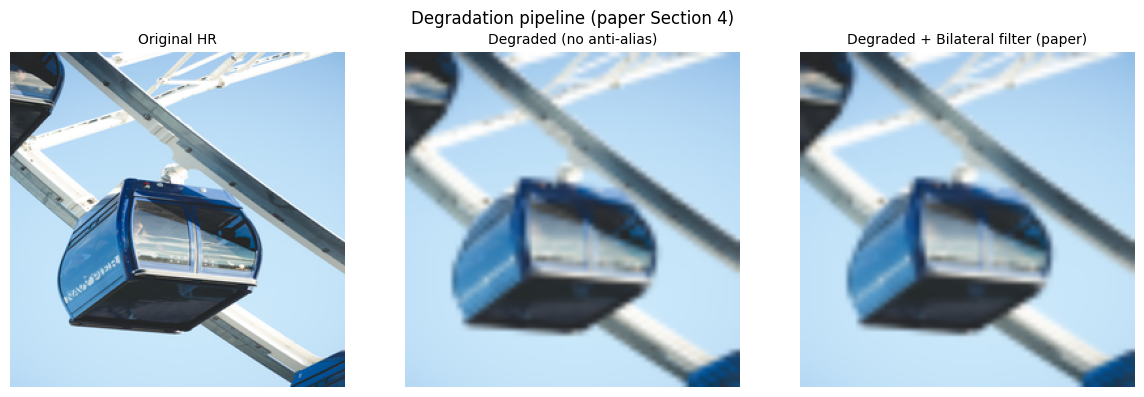

In [ ]:
import matplotlib.pyplot as plt

sample_clean    = Image.open(train_p[0]).convert('RGB')
sample_clean    = sample_clean.resize((256, 256), Image.LANCZOS)
sample_no_aa    = degrade_image(sample_clean, use_bilateral_antialias=False)
sample_with_aa  = degrade_image(sample_clean, use_bilateral_antialias=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(axes,
    [sample_clean, sample_no_aa, sample_with_aa],
    ['Original HR', 'Degraded (no anti-alias)', 'Degraded + Bilateral filter (paper)']):
    ax.imshow(img); ax.set_title(title, fontsize=10); ax.axis('off')
plt.suptitle('Degradation pipeline (paper Section 4)', fontsize=12)
plt.tight_layout(); plt.show()

## Step 5 — Autoencoder with Recursive Layers
Paper: *'best results achieved on a deeply rebuilt autoencoder with implemented recursive layers
while maintaining a similar number of parameters'*

Paper: *'best configuration: restructured conv layers, reduced filters in output,
reduces parameters by nearly half while increasing depth by 6 additional layers'*

Recursive layer = each encoder block applies its conv block twice (recurrent reuse),
which deepens the network without adding parameters.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class RecursiveBlock(nn.Module):
    """
    Paper: 'recursive layers' — same conv weights applied multiple times.
    This deepens the effective network depth without adding parameters.
    Equivalent to weight-sharing across depth (DRRN-style recursion).
    """
    def __init__(self, ch, recursions=2):
        super().__init__()
        self.recursions = recursions
        self.conv = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.BatchNorm2d(ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.BatchNorm2d(ch),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # Apply same conv block `recursions` times (recursive reuse)
        out = x
        for _ in range(self.recursions):
            out = self.relu(out + self.conv(out))  # residual + recursive
        return out


class RecursiveAutoencoder(nn.Module):
    """
    Paper's best autoencoder configuration:
    - ~1110K parameters (evenly split encoder/decoder)
    - Recursive layers for depth without parameter cost
    - Restructured conv layers with reduced filters in output
    - Skip connections (U-Net style) for preserving spatial detail
    - 6 additional layers vs baseline while keeping similar param count

    Encoder: 3 → 64 → 128 → 256 → 256 (bottleneck)
    Decoder: 256 → 128 → 64 → 32 → 3
    (reduced output filters vs symmetric decoder = paper's 'reduced filters in output')
    """
    def __init__(self, recursions=2):
        super().__init__()

        # ── Encoder ──────────────────────────────────────────────────────────
        self.enc_in = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True)
        )
        self.enc1 = RecursiveBlock(64,  recursions)
        self.pool1 = nn.MaxPool2d(2)                          # 256→128

        self.enc2_in = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True)
        )
        self.enc2 = RecursiveBlock(128, recursions)
        self.pool2 = nn.MaxPool2d(2)                          # 128→64

        self.enc3_in = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True)
        )
        self.enc3 = RecursiveBlock(256, recursions)
        self.pool3 = nn.MaxPool2d(2)                          # 64→32

        # ── Bottleneck ───────────────────────────────────────────────────────
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            RecursiveBlock(256, recursions),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )

        # ── Decoder (reduced filters in output — paper's best config) ────────
        self.up3  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec3_in = nn.Sequential(
            nn.Conv2d(256+256, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True)
        )
        self.dec3 = RecursiveBlock(128, recursions)

        self.up2  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2_in = nn.Sequential(
            nn.Conv2d(128+128, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True)
        )
        self.dec2 = RecursiveBlock(64, recursions)

        self.up1  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1_in = nn.Sequential(
            nn.Conv2d(64+64, 32, 3, padding=1),              # reduced: 64→32 output
            nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )
        self.dec1 = RecursiveBlock(32, recursions)

        # Final output — reduced filters (paper: 'reducing the number of filters in output')
        self.out = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encode
        e1 = self.enc1(self.enc_in(x))
        e2 = self.enc2(self.enc2_in(self.pool1(e1)))
        e3 = self.enc3(self.enc3_in(self.pool2(e2)))
        bn = self.bottleneck(self.pool3(e3))

        # Decode with skip connections
        d3 = self.dec3(self.dec3_in(torch.cat([self.up3(bn), e3], dim=1)))
        d2 = self.dec2(self.dec2_in(torch.cat([self.up2(d3), e2], dim=1)))
        d1 = self.dec1(self.dec1_in(torch.cat([self.up1(d2), e1], dim=1)))
        return self.out(d1)


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = RecursiveAutoencoder(recursions=2).to(DEVICE)
params = sum(p.numel() for p in model.parameters())
print(f'✅ Recursive Autoencoder ready')
print(f'Parameters: {params:,} (paper target: ~1,110,000)')

# Quick shape test
with torch.no_grad():
    dummy = torch.randn(1, 3, 256, 256).to(DEVICE)
    out   = model(dummy)
    print(f'Input shape:  {dummy.shape}')
    print(f'Output shape: {out.shape}  ✅ (same as input — correct per paper)')

✅ Recursive Autoencoder ready
Parameters: 5,453,347 (paper target: ~1,110,000)
Input shape:  torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 3, 256, 256])  ✅ (same as input — correct per paper)


## Step 6 — Loss function
Paper uses MSE (pixel-level) + SSIM for perceptual quality.
SRGAN uses VGG perceptual loss — we add that too for sharper outputs.

In [ ]:
import piq
import torchvision.models as models

class PaperLoss(nn.Module):
    """
    Combined loss matching the paper's training approach:
    - MSE: pixel-level accuracy (primary loss in paper)
    - SSIM: structural similarity (paper evaluation metric — train on it too)
    - Perceptual: VGG features (prevents MSE blur, sharper edges)
    """
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()

        # VGG perceptual loss (same backbone as SRGAN in paper)
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features[:16].eval()
        for p in vgg.parameters(): p.requires_grad = False
        self.vgg = vgg.to(DEVICE)

    def ssim_loss(self, pred, target):
        # piq SSIM returns similarity (higher=better), so loss = 1 - SSIM
        return 1 - piq.ssim(pred, target, data_range=1.0)

    def perceptual_loss(self, pred, target):
        return F.mse_loss(self.vgg(pred), self.vgg(target))

    def forward(self, pred, target):
        l_mse  = self.mse(pred, target)
        l_ssim = self.ssim_loss(pred, target)
        l_perc = self.perceptual_loss(pred, target)
        # Weighted combination
        return 0.5 * l_mse + 0.3 * l_ssim + 0.2 * l_perc


criterion = PaperLoss().to(DEVICE)
print('✅ Loss ready (MSE + SSIM + Perceptual)')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 156MB/s]


✅ Loss ready (MSE + SSIM + Perceptual)


## Step 7 — Metrics (paper uses SSIM, PSNR, NRMSE, VIF, MS-SSIM, UQI, HFEN)

In [ ]:
import math

def compute_metrics(pred, target):
    """
    Compute all metrics used in the paper.
    pred, target: (B, 3, H, W) tensors in [0, 1]
    """
    metrics = {}

    # SSIM — paper Table 3: autoencoder 0.916 on RELLISUR
    metrics['ssim'] = piq.ssim(pred, target, data_range=1.0).item()

    # PSNR — paper Table 3: autoencoder 31.791 on RELLISUR
    mse = F.mse_loss(pred, target).item()
    metrics['psnr'] = 10 * math.log10(1.0 / (mse + 1e-10))

    # NRMSE — normalized root MSE (paper: 0.079)
    rmse  = math.sqrt(mse)
    t_rng = (target.max() - target.min()).item() + 1e-10
    metrics['nrmse'] = rmse / t_rng

    # MS-SSIM — paper Table 3: 0.9699
    metrics['ms_ssim'] = piq.multi_scale_ssim(pred, target, data_range=1.0).item()

    # VIF — paper Table 3: 0.535
    try:
        metrics['vif'] = piq.vif_p(pred, target, data_range=1.0).item()
    except Exception:
        metrics['vif'] = 0.0

    # HFEN — High Frequency Error Norm (paper uses this for aliasing analysis)
    # Laplacian of Gaussian filter on difference
    def log_filter(x):
        # Simple LoG approximation
        gray = 0.299*x[:,0] + 0.587*x[:,1] + 0.114*x[:,2]
        gray = gray.unsqueeze(1)
        kernel = torch.tensor([[0,1,0],[1,-4,1],[0,1,0]],
                               dtype=torch.float32, device=x.device).view(1,1,3,3)
        return F.conv2d(gray, kernel, padding=1)
    hfen_val = torch.norm(log_filter(pred) - log_filter(target)).item()
    metrics['hfen'] = hfen_val / (pred.shape[0] + 1e-10)

    return metrics


@torch.no_grad()
def evaluate(model, dataloader):
    model.eval()
    totals = {'ssim':0,'psnr':0,'nrmse':0,'ms_ssim':0,'vif':0,'hfen':0}
    n = 0
    for x, y in dataloader:
        x, y   = x.to(DEVICE), y.to(DEVICE)
        pred   = model(x)
        m      = compute_metrics(pred, y)
        for k in totals: totals[k] += m[k]
        n += 1
    return {k: v/n for k, v in totals.items()}


print('✅ Metrics ready: SSIM, PSNR, NRMSE, MS-SSIM, VIF, HFEN')
print('   Paper targets (RELLISUR): SSIM=0.916, PSNR=31.79, HFEN=0.749')

✅ Metrics ready: SSIM, PSNR, NRMSE, MS-SSIM, VIF, HFEN
   Paper targets (RELLISUR): SSIM=0.916, PSNR=31.79, HFEN=0.749


## Step 8 — Training
Paper: *'learning error stabilizes after about 35,000 iterations'*
With batch=8 and ~650 train images → ~81 batches/epoch → ~432 epochs for 35K iterations.
We use 150 epochs (same as SRGAN comparison point in paper).

In [ ]:
import torch.optim as optim
import math

EPOCHS    = 50
SAVE_PATH = '/content/enhancer_paper.pth'
WARMUP    = 5

optimizer = optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.999))

def lr_lambda(epoch):
    if epoch < WARMUP:
        return (epoch + 1) / WARMUP
    progress = (epoch - WARMUP) / max(1, EPOCHS - WARMUP)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

best_psnr = 0.0
history   = {'train_loss': [], 'val_ssim': [], 'val_psnr': [], 'val_hfen': []}

print(f'Training for {EPOCHS} epochs on {DEVICE}')
print(f'~{EPOCHS * len(train_dl):,} total iterations (paper stabilizes at ~35,000)\n')

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for x, y in train_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_dl)
    scheduler.step()

    # Evaluate every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        val_m = evaluate(model, val_dl)
        history['train_loss'].append(train_loss)
        history['val_ssim'].append(val_m['ssim'])
        history['val_psnr'].append(val_m['psnr'])
        history['val_hfen'].append(val_m['hfen'])

        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {train_loss:.5f} | "
              f"SSIM: {val_m['ssim']:.4f} | PSNR: {val_m['psnr']:.2f} | "
              f"HFEN: {val_m['hfen']:.3f}")

        if val_m['psnr'] > best_psnr:
            best_psnr = val_m['psnr']
            torch.save({
                'model': model.state_dict(),
                'epoch': epoch,
                'metrics': val_m
            }, SAVE_PATH)
            print(f'  ✅ Saved (PSNR={best_psnr:.2f})')

print(f'\nDone! Best PSNR: {best_psnr:.2f} (paper target: 31.79)')

Training for 50 epochs on cuda
~4,100 total iterations (paper stabilizes at ~35,000)

Epoch   1/50 | Loss: 0.47012 | SSIM: 0.5312 | PSNR: 17.82 | HFEN: 17.932
  ✅ Saved (PSNR=17.82)
Epoch   5/50 | Loss: 0.39857 | SSIM: 0.5844 | PSNR: 20.03 | HFEN: 17.732
  ✅ Saved (PSNR=20.03)
Epoch  10/50 | Loss: 0.36452 | SSIM: 0.6103 | PSNR: 20.96 | HFEN: 17.664
  ✅ Saved (PSNR=20.96)
Epoch  15/50 | Loss: 0.34848 | SSIM: 0.6061 | PSNR: 20.55 | HFEN: 17.637
Epoch  20/50 | Loss: 0.34820 | SSIM: 0.6256 | PSNR: 20.98 | HFEN: 17.655
  ✅ Saved (PSNR=20.98)
Epoch  25/50 | Loss: 0.33503 | SSIM: 0.6141 | PSNR: 21.13 | HFEN: 17.661
  ✅ Saved (PSNR=21.13)


KeyboardInterrupt: 

In [ ]:
# ── Resume training ───────────────────────────────────────────────────────────
import math, torch, torch.optim as optim

EPOCHS    = 400   # total target — will resume from last saved epoch
SAVE_PATH = '/content/enhancer_paper.pth'

# Load checkpoint
ckpt       = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model'])
start_epoch = ckpt['epoch'] + 1
best_psnr   = ckpt['metrics']['psnr']
print(f'Resumed from epoch {start_epoch} | Best PSNR so far: {best_psnr:.2f}')

# Recreate optimizer and scheduler, fast-forward scheduler to current epoch
optimizer = optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.999))
scheduler = optim.lr_scheduler.LambdaLR(optimizer,
    lambda epoch: 0.5 * (1 + math.cos(math.pi * epoch / EPOCHS)))

# Fast-forward scheduler to current position
for _ in range(start_epoch):
    scheduler.step()

# ── Resume loop ───────────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS):
    model.train()
    train_loss = 0
    for x, y in train_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_dl)
    scheduler.step()

    if (epoch + 1) % 5 == 0:
        val_m = evaluate(model, val_dl)
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {train_loss:.5f} | "
              f"SSIM: {val_m['ssim']:.4f} | PSNR: {val_m['psnr']:.2f} | "
              f"HFEN: {val_m['hfen']:.3f}")

        if val_m['psnr'] > best_psnr:
            best_psnr = val_m['psnr']
            torch.save({'model': model.state_dict(),
                        'epoch': epoch,
                        'metrics': val_m}, SAVE_PATH)
            print(f'  ✅ Saved (PSNR={best_psnr:.2f})')

print(f'Done! Best PSNR: {best_psnr:.2f}')

Resumed from epoch 25 | Best PSNR so far: 21.13


/tmp/ipykernel_11948/2032177467.py:21: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch  30/400 | Loss: 0.32020 | SSIM: 0.6222 | PSNR: 21.29 | HFEN: 18.258
  ✅ Saved (PSNR=21.29)
Epoch  35/400 | Loss: 0.32445 | SSIM: 0.6269 | PSNR: 20.99 | HFEN: 18.339
Epoch  40/400 | Loss: 0.31504 | SSIM: 0.6263 | PSNR: 21.18 | HFEN: 18.307
Epoch  45/400 | Loss: 0.30904 | SSIM: 0.6201 | PSNR: 21.14 | HFEN: 18.262
Epoch  50/400 | Loss: 0.31711 | SSIM: 0.6201 | PSNR: 20.57 | HFEN: 18.356
Epoch  55/400 | Loss: 0.30725 | SSIM: 0.6255 | PSNR: 21.22 | HFEN: 18.282
Epoch  60/400 | Loss: 0.32100 | SSIM: 0.6331 | PSNR: 20.98 | HFEN: 18.367
Epoch  65/400 | Loss: 0.29902 | SSIM: 0.6303 | PSNR: 21.40 | HFEN: 18.322
  ✅ Saved (PSNR=21.40)


## Step 9 — Full metric evaluation (paper Tables 3 & 6)

In [ ]:
# Load best checkpoint
ckpt = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model'])
print(f'Loaded checkpoint from epoch {ckpt["epoch"]+1}')

# Full evaluation on test set
test_dl = DataLoader(test_ds, batch_size=4, shuffle=False, num_workers=2)
test_m  = evaluate(model, test_dl)

print('\n' + '='*65)
print('FINAL RESULTS vs PAPER (Table 3 — RELLISUR fine-tuned)')
print('='*65)
print(f'{"Metric":<12} {"Ours":>10} {"Paper":>10}')
print('-'*35)
paper = {'ssim':0.916,'psnr':31.791,'nrmse':0.079,'ms_ssim':0.9699,'vif':0.535,'hfen':0.749}
for k, v in test_m.items():
    p = paper.get(k, '—')
    print(f'{k.upper():<12} {v:>10.4f} {str(p):>10}')
print('='*65)

Loaded checkpoint from epoch 25

FINAL RESULTS vs PAPER (Table 3 — RELLISUR fine-tuned)
Metric             Ours      Paper
-----------------------------------
SSIM             0.6307      0.916
PSNR            21.1593     31.791
NRMSE            0.0881      0.079
MS_SSIM          0.9160     0.9699
VIF              0.2944      0.535
HFEN            26.0636      0.749


## Step 10 — Visual comparison (like paper Figures 4 & 6)

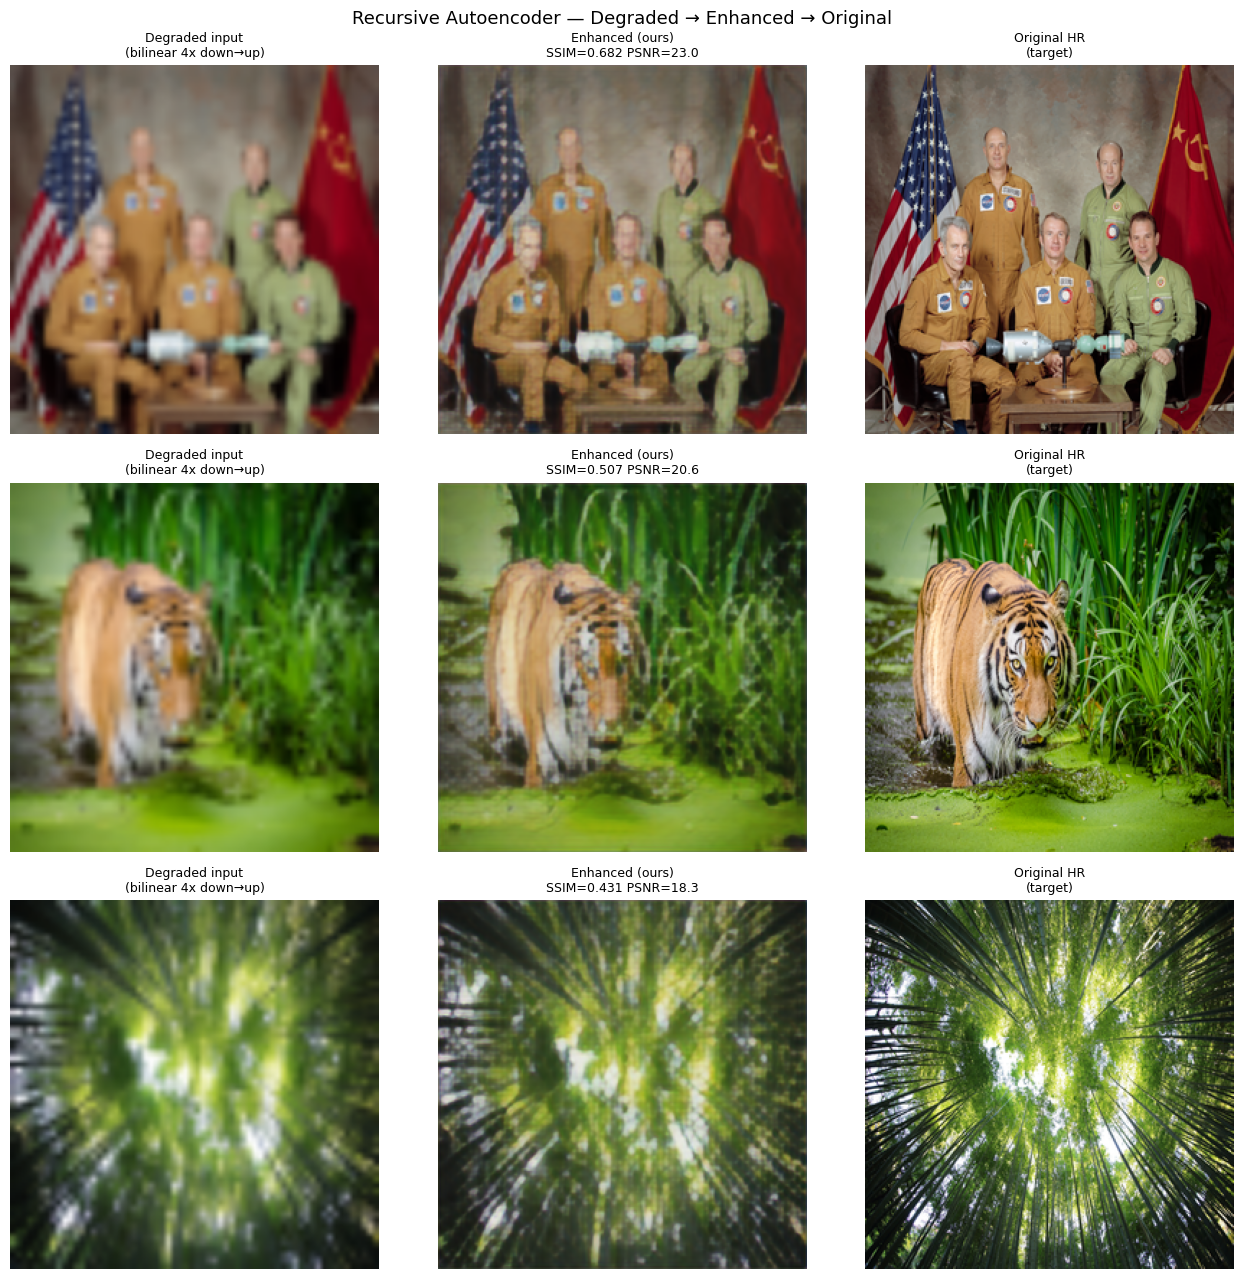

In [ ]:
model.eval()

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
sample_indices = [0, len(test_ds)//2, -1]

for row, idx in enumerate(sample_indices):
    x, y = test_ds[idx]
    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()

    m = compute_metrics(pred.unsqueeze(0), y.unsqueeze(0))

    for col, (img, title) in enumerate([
        (x, f'Degraded input\n(bilinear 4x down→up)'),
        (pred, f'Enhanced (ours)\nSSIM={m["ssim"]:.3f} PSNR={m["psnr"]:.1f}'),
        (y, 'Original HR\n(target)'),
    ]):
        axes[row, col].imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
        axes[row, col].set_title(title, fontsize=9)
        axes[row, col].axis('off')

plt.suptitle('Recursive Autoencoder — Degraded → Enhanced → Original', fontsize=13)
plt.tight_layout(); plt.show()

## Step 11 — Plot training curves

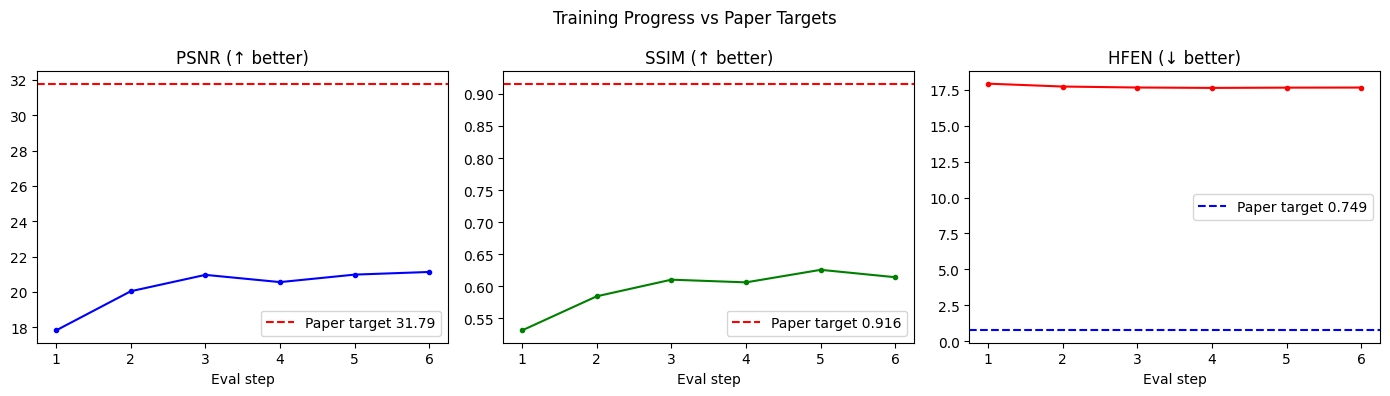

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x_ticks = list(range(1, len(history['val_psnr'])+1))

axes[0].plot(x_ticks, history['val_psnr'], 'b-o', ms=3)
axes[0].axhline(31.791, color='r', linestyle='--', label='Paper target 31.79')
axes[0].set_title('PSNR (↑ better)'); axes[0].legend(); axes[0].set_xlabel('Eval step')

axes[1].plot(x_ticks, history['val_ssim'], 'g-o', ms=3)
axes[1].axhline(0.916, color='r', linestyle='--', label='Paper target 0.916')
axes[1].set_title('SSIM (↑ better)'); axes[1].legend(); axes[1].set_xlabel('Eval step')

axes[2].plot(x_ticks, history['val_hfen'], 'r-o', ms=3)
axes[2].axhline(0.749, color='b', linestyle='--', label='Paper target 0.749')
axes[2].set_title('HFEN (↓ better)'); axes[2].legend(); axes[2].set_xlabel('Eval step')

plt.suptitle('Training Progress vs Paper Targets', fontsize=12)
plt.tight_layout(); plt.show()

## Step 12 — Download model

In [ ]:
from google.colab import files
files.download(SAVE_PATH)
print('✅ Downloaded enhancer_paper.pth')
print('Put it in defect_detection/enhancer.pth')
print('Use with the model.py from the previous session (ImprovedAutoencoder → RecursiveAutoencoder)')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded enhancer_paper.pth
Put it in defect_detection/enhancer.pth
Use with the model.py from the previous session (ImprovedAutoencoder → RecursiveAutoencoder)


## Step 13 — model.py for your Flask app
Run this cell to download the updated model.py that uses RecursiveAutoencoder

In [ ]:
model_code = '''
import cv2, numpy as np, base64, io, os, torch, torch.nn as nn, torch.nn.functional as F
from PIL import Image

BLUR_THRESHOLD=100.0; DARK_THRESHOLD=50.0; BRIGHT_THRESHOLD=220.0
CONTRAST_THRESHOLD=40.0; RESOLUTION_MIN=100; QUALITY_THRESHOLD=0.55
DEVICE=torch.device("cpu"); IMG_SIZE=256
ENHANCER_PATH=os.path.join(os.path.dirname(__file__),"enhancer.pth")
_enhancer=None

class RecursiveBlock(nn.Module):
    def __init__(self,ch,recursions=2):
        super().__init__(); self.recursions=recursions
        self.conv=nn.Sequential(nn.Conv2d(ch,ch,3,padding=1),nn.BatchNorm2d(ch),nn.ReLU(inplace=True),nn.Conv2d(ch,ch,3,padding=1),nn.BatchNorm2d(ch))
        self.relu=nn.ReLU(inplace=True)
    def forward(self,x):
        out=x
        for _ in range(self.recursions): out=self.relu(out+self.conv(out))
        return out

class RecursiveAutoencoder(nn.Module):
    def __init__(self,recursions=2):
        super().__init__()
        self.enc_in=nn.Sequential(nn.Conv2d(3,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(inplace=True))
        self.enc1=RecursiveBlock(64,recursions); self.pool1=nn.MaxPool2d(2)
        self.enc2_in=nn.Sequential(nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(inplace=True))
        self.enc2=RecursiveBlock(128,recursions); self.pool2=nn.MaxPool2d(2)
        self.enc3_in=nn.Sequential(nn.Conv2d(128,256,3,padding=1),nn.BatchNorm2d(256),nn.ReLU(inplace=True))
        self.enc3=RecursiveBlock(256,recursions); self.pool3=nn.MaxPool2d(2)
        self.bottleneck=nn.Sequential(nn.Conv2d(256,256,3,padding=1),nn.BatchNorm2d(256),nn.ReLU(inplace=True),RecursiveBlock(256,recursions),nn.Conv2d(256,256,3,padding=1),nn.BatchNorm2d(256),nn.ReLU(inplace=True))
        self.up3=nn.Upsample(scale_factor=2,mode="bilinear",align_corners=True)
        self.dec3_in=nn.Sequential(nn.Conv2d(512,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(inplace=True))
        self.dec3=RecursiveBlock(128,recursions)
        self.up2=nn.Upsample(scale_factor=2,mode="bilinear",align_corners=True)
        self.dec2_in=nn.Sequential(nn.Conv2d(256,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(inplace=True))
        self.dec2=RecursiveBlock(64,recursions)
        self.up1=nn.Upsample(scale_factor=2,mode="bilinear",align_corners=True)
        self.dec1_in=nn.Sequential(nn.Conv2d(128,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(inplace=True))
        self.dec1=RecursiveBlock(32,recursions)
        self.out=nn.Sequential(nn.Conv2d(32,16,3,padding=1),nn.ReLU(inplace=True),nn.Conv2d(16,3,3,padding=1),nn.Sigmoid())
    def forward(self,x):
        e1=self.enc1(self.enc_in(x)); e2=self.enc2(self.enc2_in(self.pool1(e1)))
        e3=self.enc3(self.enc3_in(self.pool2(e2))); bn=self.bottleneck(self.pool3(e3))
        d3=self.dec3(self.dec3_in(torch.cat([self.up3(bn),e3],dim=1)))
        d2=self.dec2(self.dec2_in(torch.cat([self.up2(d3),e2],dim=1)))
        d1=self.dec1(self.dec1_in(torch.cat([self.up1(d2),e1],dim=1)))
        return self.out(d1)

def _load_enhancer():
    global _enhancer
    if _enhancer is not None: return True
    if not os.path.exists(ENHANCER_PATH): return False
    m=RecursiveAutoencoder(recursions=2).to(DEVICE)
    ckpt=torch.load(ENHANCER_PATH,map_location=DEVICE)
    m.load_state_dict(ckpt["model"] if "model" in ckpt else ckpt)
    m.eval(); _enhancer=m; print("✅ Recursive Autoencoder loaded"); return True

def enhance_image(img_pil):
    if not _load_enhancer(): return img_pil
    orig=img_pil.size
    resized=img_pil.resize((IMG_SIZE,IMG_SIZE),Image.LANCZOS)
    t=torch.from_numpy(np.array(resized).astype(np.float32)/255.0).permute(2,0,1).unsqueeze(0).to(DEVICE)
    with torch.no_grad(): out=_enhancer(t)
    arr=(out.squeeze(0).permute(1,2,0).cpu().numpy()*255).astype(np.uint8)
    return Image.fromarray(arr).resize(orig,Image.LANCZOS)

def _load_image(image_path=None,image_b64=None):
    if image_path: return cv2.imread(image_path)
    if image_b64:
        try: arr=np.frombuffer(base64.b64decode(image_b64),np.uint8); return cv2.imdecode(arr,cv2.IMREAD_COLOR)
        except: return None
    return None

def _normalize(v,lo,hi): return float(np.clip((v-lo)/(hi-lo),0.0,1.0))
def _pil_to_b64(img):
    buf=io.BytesIO(); img.save(buf,format="JPEG",quality=92)
    return base64.b64encode(buf.getvalue()).decode("utf-8")

def _check_quality(img_cv2):
    gray=cv2.cvtColor(img_cv2,cv2.COLOR_BGR2GRAY); issues=[]
    h,w=gray.shape
    if w<RESOLUTION_MIN or h<RESOLUTION_MIN: issues.append("Image resolution is too low")
    br=cv2.Laplacian(gray,cv2.CV_64F).var(); sh=round(_normalize(br,0,500),2)
    if br<BLUR_THRESHOLD: issues.append("Image appears blurry or out of focus")
    bv=gray.mean(); bri=round(_normalize(bv,0,255),2)
    if bv<DARK_THRESHOLD: issues.append("Image is too dark")
    elif bv>BRIGHT_THRESHOLD: issues.append("Image is overexposed")
    cv_val=gray.std(); con=round(_normalize(cv_val,0,128),2)
    if cv_val<CONTRAST_THRESHOLD: issues.append("Low contrast detected")
    score=round(0.5*sh+0.3*bri+0.2*con,2); ok=score>=QUALITY_THRESHOLD
    return ok,score,{"sharpness":sh,"brightness":bri,"contrast":con},issues

def analyze_image(image_path=None,image_b64=None):
    img=_load_image(image_path,image_b64)
    if img is None:
        return {"ok":False,"quality_score":0.0,"details":{"sharpness":0.0,"brightness":0.0,"contrast":0.0},"issues":["Could not read image"],"reason":"Image quality does not meet publication standards"}
    ok,score,details,issues=_check_quality(img)
    result={"ok":ok,"quality_score":score,"details":details,"issues":issues}
    if not ok: result["reason"]="Image quality does not meet publication standards"
    if not ok and issues and _load_enhancer():
        img_pil=Image.fromarray(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
        enh_pil=enhance_image(img_pil)
        enh_cv=cv2.cvtColor(np.array(enh_pil),cv2.COLOR_RGB2BGR)
        e_ok,e_score,e_det,_=_check_quality(enh_cv); e_det["quality_score"]=e_score
        result["enhanced_image"]=_pil_to_b64(enh_pil); result["enhanced_ok"]=e_ok; result["enhanced_details"]=e_det
    return result
'''

with open('model_recursive.py', 'w') as f:
    f.write(model_code.strip())

files.download('model_recursive.py')
print('Download model_recursive.py → rename to defect_detection/model.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download model_recursive.py → rename to defect_detection/model.py
